# Sampling NLA Amplitudes for Machine-Learning Compression

`NLA.ipynb` defined the individual factors and `POWER.ipynb` recombined them into the
signed amplitude $\mathcal A_{\rm IA}$. This notebook turns the model into collections
of amplitude surfaces that can be used to develop and test ML-based compression.

## The path through the notebook

The notebook has two stages:

- a completed nuisance-only example at fixed cosmology;
- a student assignment that extends the sample to cosmological and nuisance parameters.

By the end, you should be able to:

- translate parameter ranges into a reproducible parameter matrix;
- generate amplitude tensors with explicit and verified shapes;
- inspect random models before using them for ML;
- preserve factorized components and metadata when saving a dataset;
- distinguish nuisance-only compression from joint cosmology–nuisance compression.

The ranges used here are broad teaching ranges, not observational priors.

---

## Set up an independent sampling notebook

This notebook imports the canonical functions from `Alignment.py` and can run from a
fresh kernel. The nuisance-only example does not calculate the matter power spectrum,
which keeps sample generation inexpensive.

In [1]:
import json
import sys
from pathlib import Path

import numpy
import pyccl
from matplotlib import pyplot

In [2]:
pyplot.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 20,
    "text.usetex": True,
})

In [3]:
base_path = Path.cwd().parent if Path.cwd().name == "Code" else Path.cwd()
code_path = base_path / "Code"
data_path = base_path / "Data"

if str(code_path) not in sys.path:
    sys.path.insert(0, str(code_path))

from Alignment import Z_STAR, NLAModel, cosmological_factor, pivot_redshift_ratio

print("Project directory:", base_path)
print("Code directory:   ", code_path)
print("Data directory:   ", data_path)

Project directory: /Users/s2227120/Downloads/IAFlowCloud
Code directory:    /Users/s2227120/Downloads/IAFlowCloud/Code
Data directory:    /Users/s2227120/Downloads/IAFlowCloud/Data


---

## Define the first compression targets

At fixed cosmology, the shape target is

$$
\mathcal A_\Theta(k,z\mid\boldsymbol\Theta)
=R_z(z)R_L(z)S(k,z),
\qquad R_z(z)=r_\ast^\eta(z),
$$

with

$$
\boldsymbol\Theta=
(\eta,\xi,s,z_q,q,n^\ast,k_t^\ast,\alpha,m,\gamma_t,\gamma_n).
$$

The complete nuisance component includes the scalar normalization,

$$
\boxed{\mathcal A_{\rm nuisance}=A_0\mathcal A_\Theta.}
$$

We also retain $S(k,z)$ explicitly. This makes it possible to test whether an ML
latent representation preserves the new scale--redshift physics rather than only
reconstructing the final product.

### Choose reproducible teaching ranges

The canonical sampled order is

$$
(A_0,\eta,\xi,s,z_q,q,n^\ast,k_t^\ast,\alpha,m,\gamma_t,\gamma_n).
$$

| Parameter | Teaching range | Sampling rule |
|---|---:|---|
| $A_0$ | $[0.2,3.0]$ | uniform |
| $\eta$ | $[-2,2]$ | uniform |
| $\xi$ | $[-3,3]$ | uniform |
| $s$ | $[1,8]$ | uniform |
| $z_q$ | $[0.2,2.0]$ | uniform |
| $q$ | $[0,1.5]$ | uniform |
| $n^\ast$ | $[1.5,4]$ | uniform |
| $k_t^\ast$ | $[0.03,0.6],{\rm Mpc}^{-1}$ | log-uniform |
| $\alpha$ | $[-0.3,0.3]$ | uniform |
| $m$ | $[1,4]$ | uniform; deliberately conservative |
| $\gamma_t$ | $[-0.75,0.75]$ | uniform |
| $\gamma_n$ | $[-0.5,0.5]$ | uniform |

These are transparent teaching ranges, not observational priors. They are broad
enough to produce varied surfaces but controlled enough to keep $S(k,z)$ positive
and smooth on the chosen training grid.

In [4]:
rng = numpy.random.default_rng(2026)
number_of_models = 300

nuisance_parameter_names = list(NLAModel.SAMPLED_PARAMETER_NAMES)

nuisance_parameters = numpy.column_stack([
    rng.uniform(0.2, 3.0, number_of_models),
    rng.uniform(-2.0, 2.0, number_of_models),
    rng.uniform(-3.0, 3.0, number_of_models),
    rng.uniform(1.0, 8.0, number_of_models),
    rng.uniform(0.2, 2.0, number_of_models),
    rng.uniform(0.0, 1.5, number_of_models),
    rng.uniform(1.5, 4.0, number_of_models),
    10.0**rng.uniform(numpy.log10(0.03), numpy.log10(0.6), number_of_models),
    rng.uniform(-0.3, 0.3, number_of_models),
    rng.uniform(1.0, 4.0, number_of_models),
    rng.uniform(-0.75, 0.75, number_of_models),
    rng.uniform(-0.5, 0.5, number_of_models),
])

z_training = numpy.asarray([0.2, 0.5, 0.8, 1.2, 1.6, 2.0])
k_training = numpy.logspace(-3, 0.5, 96)
r_star_training = pivot_redshift_ratio(z_training, z_star=Z_STAR)

print("nuisance parameters:", nuisance_parameters.shape)
print("redshift grid:      ", z_training.shape)
print("wavenumber grid:    ", k_training.shape)
print("r_star grid:        ", r_star_training)

nuisance parameters: (300, 8)
redshift grid:       (6,)
wavenumber grid:     (96,)


---

## Generate nuisance-only amplitude samples

Each parameter row produces one $(N_z,N_k)$ surface. The explicit loop keeps the
mapping between a parameter row and an amplitude surface easy to inspect:

$$
\texttt{nuisance\_parameters}[i]
\longrightarrow
\mathcal A_\Theta^{(i)}
\longrightarrow
\mathcal A_{\rm nuisance}^{(i)}.
$$

In [5]:
amplitude_shape = (number_of_models, len(z_training), len(k_training))

S_k_z_samples = numpy.empty(amplitude_shape)
A_theta_samples = numpy.empty(amplitude_shape)
A_nuisance_samples = numpy.empty(amplitude_shape)

for model_index, values in enumerate(nuisance_parameters):
    model = NLAModel.from_array(values, z_star=Z_STAR)
    S_k_z = model.scale_dependence(z_training, k_training)
    A_theta = model.model_amplitude(z_training, k_training)

    S_k_z_samples[model_index] = S_k_z
    A_theta_samples[model_index] = A_theta
    A_nuisance_samples[model_index] = model.A0 * A_theta

print("S_k_z samples:     ", S_k_z_samples.shape)
print("A_theta samples:   ", A_theta_samples.shape)
print("A_nuisance samples:", A_nuisance_samples.shape)

A_theta samples:    (300, 6, 96)
A_nuisance samples: (300, 6, 96)


### Validate the generated tensor

Before plotting or saving, verify the number of models, shapes, finiteness, positive
scale factors, exact nuisance recombination, the canonical class parameter order,
and the pivot identity $r_\ast(z_\ast)=1$.

In [6]:
expected_shape = (number_of_models, len(z_training), len(k_training))
recombined_nuisance = nuisance_parameters[:, 0, None, None] * A_theta_samples

assert nuisance_parameter_names == list(NLAModel.SAMPLED_PARAMETER_NAMES)
assert nuisance_parameters.shape == (
    number_of_models,
    len(nuisance_parameter_names),
)
assert S_k_z_samples.shape == expected_shape
assert A_theta_samples.shape == expected_shape
assert A_nuisance_samples.shape == expected_shape
assert numpy.all(numpy.isfinite(S_k_z_samples))
assert numpy.all(numpy.isfinite(A_theta_samples))
assert numpy.all(numpy.isfinite(A_nuisance_samples))
assert numpy.all(S_k_z_samples > 0.0)
assert numpy.allclose(A_nuisance_samples, recombined_nuisance)

pivot_index = numpy.flatnonzero(numpy.isclose(z_training, Z_STAR))[0]
assert numpy.isclose(r_star_training[pivot_index], 1.0)

print("All nuisance-only dataset checks passed.")

All nuisance-only dataset checks passed.


### Inspect random models

Plot $S(k,z)$ both at the pivot and at high redshift, then inspect the corresponding
$\mathcal A_\Theta$. Smooth but visibly different curves confirm that the parameter
ranges exercise scale, redshift, and their interaction before ML training begins.

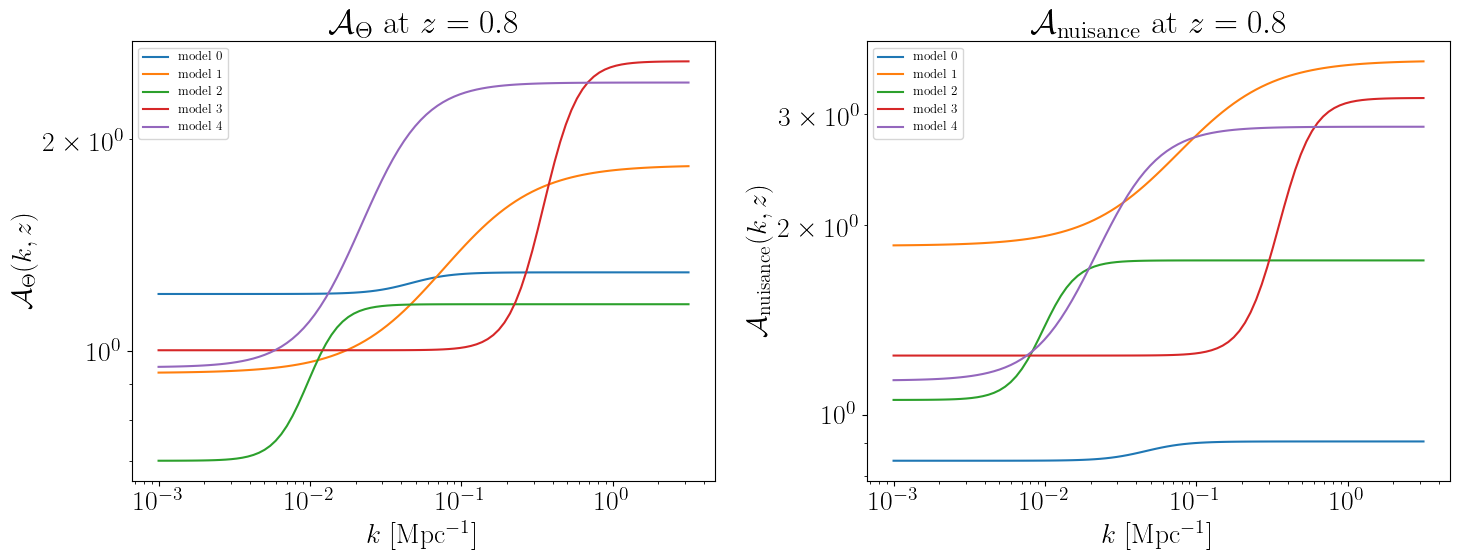

In [7]:
selected_models = [0, 1, 2, 3, 4]
pivot_index = numpy.flatnonzero(numpy.isclose(z_training, Z_STAR))[0]
high_redshift_index = -1

figure, axes = pyplot.subplots(1, 3, figsize=(19, 6))

for model_index in selected_models:
    label = f"model {model_index}"
    axes[0].plot(k_training, S_k_z_samples[model_index, pivot_index], label=label)
    axes[1].plot(k_training, S_k_z_samples[model_index, high_redshift_index], label=label)
    axes[2].plot(k_training, A_theta_samples[model_index, high_redshift_index], label=label)

axes[0].set_title(r"$S(k,z_\ast)$")
axes[1].set_title(rf"$S(k,z={z_training[high_redshift_index]})$")
axes[2].set_title(rf"$\mathcal A_\Theta$ at $z={z_training[high_redshift_index]}$")

for axis in axes:
    axis.set_xscale("log")
    axis.set_xlabel(r"$k$ [Mpc$^{-1}$]")
    axis.legend(fontsize=9)

axes[0].set_ylabel(r"$S(k,z_\ast)$")
axes[1].set_ylabel(r"$S(k,z)$")
axes[2].set_ylabel(r"$\mathcal A_\Theta(k,z)$")
figure.tight_layout()
pyplot.show()

### Save the factorized nuisance dataset

Save raw amplitudes and complete metadata before applying logarithms, standardization,
PCA, or neural compression. Preprocessing should be reproducible from this physical
dataset.

In [8]:
nuisance_metadata = {
    "random_seed": 2026,
    "sampling_method": "independent uniform and log-uniform",
    "fixed_cosmology": True,
    "z_star": Z_STAR,
    "r_star_definition": "(1 + z) / (1 + z_star)",
    "R_z_definition": "r_star**eta",
    "S_k_z_definition": "joint scale-redshift transition with evolving k_t and n",
    "A_theta_definition": "R_z * R_L * S_k_z",
    "A_nuisance_definition": "A0 * A_theta",
    "m_range": [1.0, 4.0],
}

nuisance_output_file = data_path / "nla_nuisance_amplitudes.npz"

numpy.savez_compressed(
    nuisance_output_file,
    z=z_training,
    r_star=r_star_training,
    k=k_training,
    nuisance_parameters=nuisance_parameters,
    nuisance_parameter_names=numpy.asarray(nuisance_parameter_names),
    S_k_z=S_k_z_samples,
    A_theta=A_theta_samples,
    A_nuisance=A_nuisance_samples,
    metadata=numpy.asarray(json.dumps(nuisance_metadata)),
)

print("Saved:", nuisance_output_file.resolve())

Saved: /Users/s2227120/Downloads/IAFlowCloud/Data/nla_nuisance_amplitudes.npz


---

# Student assignment: sample cosmology and nuisance parameters

Extend the completed example to generate

$$
\boxed{
\mathcal A_{\rm IA}(k,z)
=
-\mathcal A_\Omega(z)
\mathcal A_{\rm nuisance}(k,z).
}
$$

The assignment deliberately preserves the factorized arrays. This lets later
compression experiments determine whether information loss originates in the
cosmological scaling, nuisance surface, or final recombination.

Use a controlled cosmological subset:

$$
\boldsymbol\Omega_{\rm sample}
=
(\Omega_c,w_0,w_a),
$$

while keeping the remaining entries of `Planck.json` fixed.

| Parameter | Teaching range |
|---|---:|
| $\Omega_c$ | $[0.22,0.31]$ |
| $w_0$ | $[-1.2,-0.8]$ |
| $w_a$ | $[-0.5,0.5]$ |

The cosmology ranges are illustrative and are not a joint observational prior.

## Provided cosmology setup

Only $\Omega_m/D(z)$ is required for this assignment, so the helper below uses the
fast Eisenstein--Hu transfer function rather than repeatedly initializing CAMB.

In [9]:
with open(data_path / "Planck.json", "r", encoding="utf-8") as file:
    parameter = json.load(file)


def create_sampled_cosmology(Omega_c, w0, wa):
    '''Create a fast PyCCL cosmology for the joint-sampling exercise.'''
    return pyccl.cosmology.Cosmology(
        h=parameter["H"],
        w0=w0,
        wa=wa,
        A_s=parameter["AS"],
        n_s=parameter["NS"],
        m_nu=parameter["MNU"],
        T_CMB=parameter["TCMB"],
        Omega_k=parameter["OMEGAK"],
        Omega_c=Omega_c,
        Omega_b=parameter["OMEGAB"],
        mass_split="normal",
        transfer_function="eisenstein_hu",
    )


cosmology_parameter_names = [
    "Omega_c",
    "w0",
    "wa",
]

## Draw the joint parameter matrices

Create a reproducible sample containing `cosmology_parameters` with shape
`(number_of_joint_models, 3)` and `joint_nuisance_parameters` with shape
`(number_of_joint_models, 12)`. Use the same canonical nuisance ordering as the
completed example, including free but conservative $m\in[1,4]$.

In [10]:
# Student workspace: draw cosmological and nuisance parameter matrices.
number_of_joint_models = 100
joint_random_seed = 2027

# Add your sampling code below.

## Evaluate the cosmological component

For each cosmological parameter row:

- create a PyCCL cosmology with `create_sampled_cosmology`;
- evaluate `cosmological_factor` on `z_training`;
- store the result in `A_omega_samples`.

The expected shape is

```python
(number_of_joint_models, len(z_training))
```

In [11]:
# Student workspace: construct each cosmology and evaluate A_omega.

# Add your implementation below.

## Generate and recombine the joint amplitudes

Construct each nuisance model with `NLAModel.from_array`, then retain
$S(k,z)$, $\mathcal A_\Theta$, and $\mathcal A_{\rm nuisance}$. Broadcast the
cosmological component as

$$
\mathcal A_{\rm IA}^{(i)}
=-\mathcal A_\Omega^{(i)}[:,{\tt None}]
\mathcal A_{\rm nuisance}^{(i)}.
$$

Store `A_omega_samples`, `S_k_z_joint`, `A_theta_joint`,
`A_nuisance_joint`, and `A_IA_samples` so physical information can be checked after
compression.

In [12]:
# Student workspace: generate A_theta, A_nuisance, and A_IA.

# Add your implementation below.

## Validate and inspect the joint sample

Check all shapes and finite values, $S(k,z)>0$, exact reconstruction of
$\mathcal A_{\rm IA}=-\mathcal A_\Omega\mathcal A_{\rm nuisance}$, negative signed
amplitudes for positive $A_0$, reproducibility from the seed, and visible variation
from cosmological and nuisance parameters. Include diagnostic curves for
$\mathcal A_\Omega(z)$, $S(k,z)$, and $\mathcal A_{\rm IA}(k,z)$.

In [13]:
# Student workspace: add assertions and diagnostic plots.

# Add your validation code below.

## Save the joint dataset

Save `Data/nla_joint_amplitudes.npz` with `z`, `r_star`, `k`, both parameter
matrices and name arrays, `A_omega`, `S_k_z`, `A_theta`, `A_nuisance`, `A_IA`, and
metadata. Record the seed, sampling rules, ranges, $z_\ast$, the $r_\ast$ and $R_z$
definitions, and all amplitude definitions.

In [14]:
# Student workspace: save the validated factorized joint dataset.
joint_output_file = data_path / "nla_joint_amplitudes.npz"

# Add your saving code below.

---

## Final takeaway

The nuisance-only dataset isolates model-dependent variation and provides the simplest
compression benchmark. The joint dataset adds cosmological growth variation while
retaining every factorized component needed for validation.

Joint sampling does not by itself guarantee that a learned compression preserves
cosmological information. That must be tested later through reconstruction diagnostics,
parameter sensitivity, or downstream inference.